# Direct integration with `RCTD` on the Visium adult mouse brain dataset

In [1]:
set.seed(20250626)
library(Matrix)
library(spacexr)
library(MCube)
library(ggplot2)

In [2]:
RESULT_PATH <- "/import/home/share/zw/pql/results/mouse_brain/reliability"

## Cell type deconvolution results from `RCTD`

In [3]:
myRCTD <- readRDS(file.path(RESULT_PATH, "visium_1", "myRCTD.rds"))

## Integration of `MCube` and `RCTD` using one line of code

In [4]:
mcube_object <- mcubeRCTD(myRCTD, RCTD_mode = "full", num_workers = 36, num_threads = 1, shared_memory = TRUE)

The batch_id is not provided!
All spots are assumed to be from the same batch and share the same gene platform effects.

Select high-abundance cell types to analyze with proportion_threshold = 0.1 and celltype_threshold = 100.

mcubeFilterCellTypes: Cell type(s) Ext_L23, Oligo_2, Inh_1, Ext_Thal_1, Ext_Thal_2, Inh_4, Astro_HPC pass the threshold.

Cell type(s) Astro_THAL_med, Inh_Sst, Inh_6, Ext_L5_3, Inh_Meis2_3, Micro, Ext_L5_2, Ext_Pir, Astro_AMY, Inh_2, Inh_Pvalb, Inh_Lamp5, Ext_L25, Nb_2, Ext_L56, Ext_Unk_2, Ext_Unk_3, Inh_3, Ext_Amy_2, Ext_L5_1, OPC_1, Astro_AMY_CTX, Ext_Hpc_DG1, Astro_HYPO, Inh_Meis2_1, Ext_Hpc_DG2, Ext_Med, Inh_Meis2_2, Ext_Hpc_CA1, Ext_L6B, Astro_CTX, Ext_Amy_1, Astro_WM, Oligo_1, Astro_STR, Ext_L6, Astro_THAL_lat, Nb_1, LowQ_2, Inh_Vip, Ext_ClauPyr, Ext_Hpc_CA2, OPC_2, Inh_5, Ext_Hpc_CA3, Ext_Unk_1, Inh_Meis2_4, Unk_2, Astro_THAL_hab, LowQ_1, Endo has/have less than the minimum celltype_threshold = 100 with proportion_threshold = 0.1.
To include the above cel

## Visiualization

### Cell type proportions

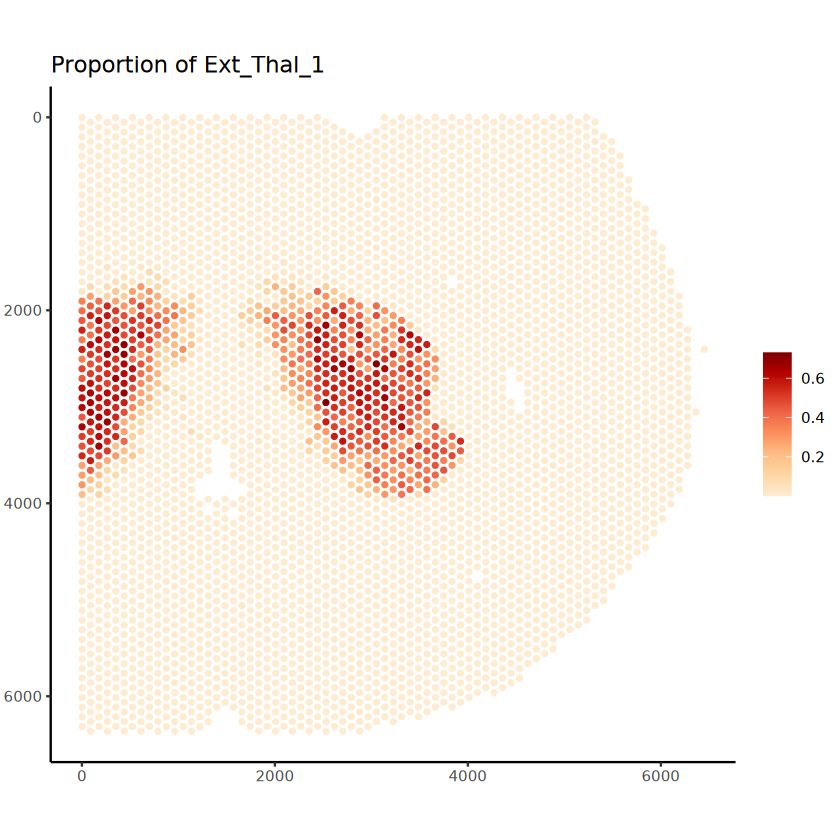

In [5]:
celltype <- "Ext_Thal_1"
mcubePlotPropCellType(mcube_object@proportions, mcube_object@coordinates, celltype)

In [6]:
head(mcubeGetSigGenes(mcube_object@pvalues)[[celltype]])

mcubeGetSigGenes: Set adjust_method as BH and alpha as 0.05.



,pvalue,adjusted_pvalue
,<dbl>,<dbl>
Pcp4,8.069989e-70,7.037030e-67
Cplx1,1.206592e-62,5.260740e-60
Atp1b1,4.314774e-50,1.254161e-47
Snap25,2.196608e-41,4.788606e-39
Nsmf,3.104560e-39,5.414353e-37
Nefm,1.083976e-33,1.575379e-31


### Overall gene expression

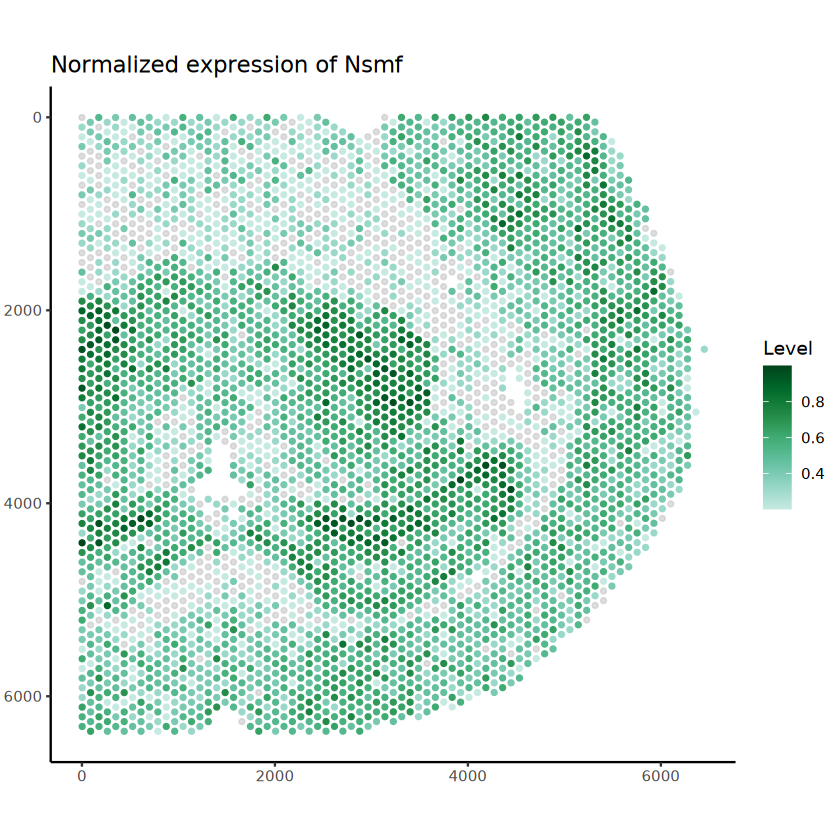

In [7]:
gene <- "Nsmf"
mcubePlotExpr(mcube_object@counts, mcube_object@coordinates, gene, background = TRUE)

### Gene expression variations within a specific cell type

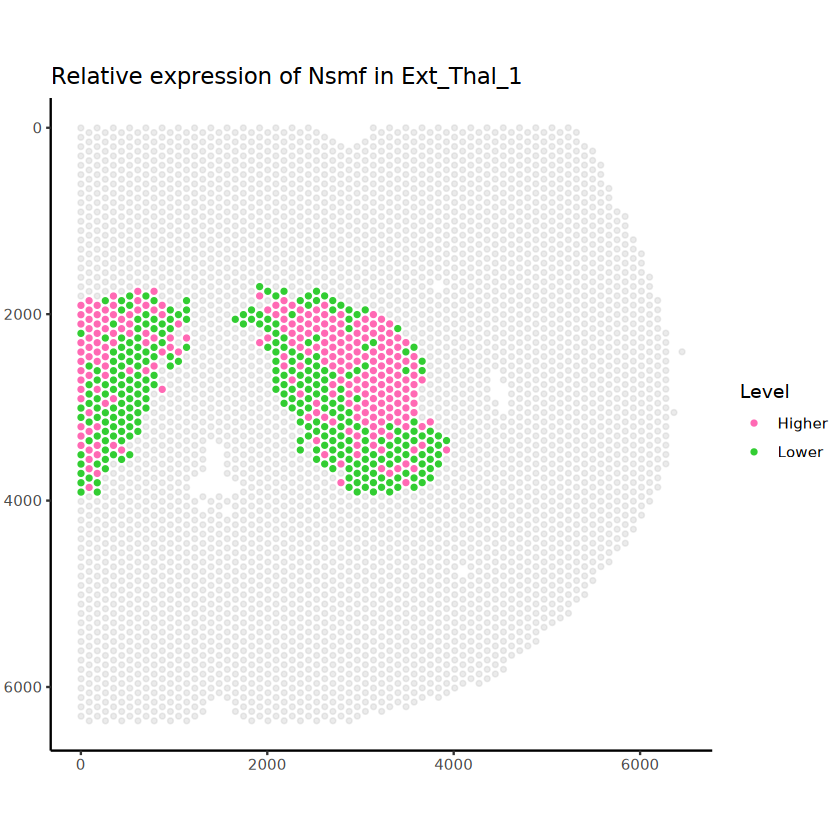

In [8]:
mcubePlotExprCellTypeBinary(mcube_object, celltype, gene, background = TRUE)